# Triangulacja Delaunaya: Python vs Rust vs C++

## 1. Problem i Algorytm
* **Czym jest Triangulacja Delaunaya?** Reguła pustego okręgu i maksymalizacja najmniejszych kątów.
* **Algorytm Bowyera-Watsona:** Super-trójkąt, szukanie złych trójkątów, wydrążenie dziury, re-triangulacja.
* **Algorytm Divide & Conquer:** Sortowanie, podział (divide), rozwiązanie bazowe, zszywanie (conquer/merge).
* **Złożoność Obliczeniowa:**
  * Bowyer-Watson wersja naiwna: O(N^2)
  * Bowyer-Watson wersja zoptymalizowana (Triangle Walk): O(N√N)
  * Algorytm Divide & Conquer: O(N log N)

---

## 2. Decyzje Architektoniczne i Zarządzanie Pamięcią (Bowyer-Watson)

### 2.1. Grafy Obiektowe vs Data-Oriented Design
* **Python:** Klasyczne podejście OOP. Trójkąty na stercie, wektory pełne wskaźników do innych obiektów.
  ```python
  class Triangle:
      def __init__(self, p0, p1, p2):
          self.vertices = [p0, p1, p2]         # referencje do obiektow Point
          self.neighbors = [None, None, None]  # referencje do obiektow Triangle
  ```
* **Rust i C++:** Płaskie wektory (Vec, std::vector). Poruszanie się po indeksach, idealna lokalność pamięci podręcznej (Cache Locality).
  ```cpp
  struct WorkingTriangle {
      std::array<size_t, 3> vertices;  // zwykle liczby calkowite
      std::array<size_t, 3> neighbors; // zwykle liczby calkowite
  };
  ```
* **Dlaczego zrezygnowaliśmy z std::shared_ptr w C++?** Uniknięcie cykli referencyjnych i drastycznego narzutu na wielowątkowe liczniki odwołań.

### 2.2. Prealokacja i Twierdzenie Eulera
* **Python:** Dynamicznie rosnące listy -> realokacja i kopiowanie danych w tle.
  ```python
  self.triangles.extend(new_triangles)
  ```
* **Rust i C++:** Wykorzystanie twierdzenia Eulera dla grafów planarnych (Max ≈ 2N). Użycie `reserve() / with_capacity()` na starcie -> brak alokacji w trakcie
  ```rust
  let mut triangles = Vec::with_capacity(points.len() * 2); 
  ```
### 2.4. Walka z Borrow Checkerem

Kategoryczny zakaz mutowania pożyczonych danych w Ruście zmusza do obchodzenia zasad Borrow Checkera, podczas gdy C++ pozwala na swobodne referencje. Prowadzi to do dwóch głównych różnic w implementacji:

**Problem 1: Kopiowanie przed edycją (Oznaczanie złych trójkątów)**
* **Rust:** Nie możemy pożyczyć trójkąta by odczytać jego sąsiadów, i w tym samym czasie zmutować jego flagi. Musimy stworzyć pełną kopię obiektu w pamięci (trait `Copy`), odczytać dane, i osobną operacją zaktualizować wektor.
  ```rust
  for &bad_idx in &bad_triangles {
      // kopiowanie calego trojkata
      let tri = self.triangles[bad_idx]; 
      for i in 0..3 {
          let neighbor_idx = tri.neighbors[i];
          // ... logika sprawdzania granic
      }
      // osobne odwolanie do wektora w celu zmiany
      self.triangles[bad_idx].active = false; 
  }
  ```
* **C++:** Po prostu wyciągamy bezpośrednią referencję, czytamy co potrzebujemy i od razu modyfikujemy obiekt.
  ```cpp
  for (size_t bad_idx : bad_triangles) {
      // bezposrednia referencja
      auto& tri = triangles[bad_idx]; 
      for (size_t i = 0; i < 3; ++i) {
          size_t n_idx = tri.neighbors[i];
          // ... logika sprawdzania granic
      }
      // zmiana prosto na wyciagnietej referencji
      tri.active = false; 
  }
  ```

**Problem 2: Rozdzielanie pętli (Zszywanie nowych trójkątów z sąsiadami)**
* **Rust:** Dodawanie nowego trójkąta (`.push()`) blokuje cały wektor do zapisu. Nie możemy w tej samej pętli zmodyfikować starych sąsiadów, bo to wymagałoby drugiego, jednoczesnego dostępu do zapisu (`&mut self.triangles[n_idx]`). 
  ```rust
  // PETLA 1 Tylko tworzenie nowych trojkatow i dolaczanie do wektora
  for (j, &(p1, p2, outer_neighbor)) in boundary.iter().enumerate() {
      let new_tri = WorkingTriangle { /* ... */ };
      self.triangles.push(new_tri); 
  }

  // PETLA 2 Tylko aktualizacja starych sasiadow
  for (j, &(_, p2, outer_neighbor)) in boundary.iter().enumerate() {
      if let Some(n_idx) = outer_neighbor {
          let n_tri = &mut self.triangles[n_idx]; 
          for k in 0..3 {
              if n_tri.vertices[k] == p2 && n_tri.vertices[(k + 1) % 3] == p1 {
                  n_tri.neighbors[k] = Some(base_idx + j);
                  break;
              }
          }
      }
  }
  ```
* **C++:** Pełna kontrola nad pamięcią pozwala nam dodawać nowe elementy na koniec wektora i jednocześnie modyfikować stare w jednym przejściu.
  ```cpp
  // jedna  petla
  for (size_t j = 0; j < boundary.size(); ++j) {
      size_t new_tri_idx = base_idx + j;
      
      // dodanie nowego trpjkata
      triangles.emplace_back(std::array<size_t, 3>{boundary[j].p1, boundary[j].p2, point_idx},
                             std::array<size_t, 3>{boundary[j].outer, NO_NEIGHBOR, NO_NEIGHBOR});

      // modyfikacja sasiada
      size_t n_idx = boundary[j].outer;
      if (n_idx != NO_NEIGHBOR) {
          auto& n_tri = triangles[n_idx];
          for (size_t k = 0; k < 3; ++k) {
              if (n_tri.vertices[k] == boundary[j].p2 && n_tri.vertices[(k + 1) % 3] == boundary[j].p1) {
                  n_tri.neighbors[k] = new_tri_idx;
                  break;
              }
          }
      }
  }
  ```

### 2.5. Reprezentacja "Braku Sąsiada" (Nullability)
* **Python:** Typowanie dynamiczne i None
  ```python
  if current.neighbors[i] is None:
      return current
  ```
* **Rust:** Monadyczny typ Option<usize>
  ```rust
  if let Some(next_idx) = tri.neighbors[i] {
      curr = next_idx;
  }
  ```
* **C++:** Sentinel Value NO_NEIGHBOR
  ```cpp
  const size_t NO_NEIGHBOR = std::numeric_limits<size_t>::max(); 
  if (tri.neighbors[i] != NO_NEIGHBOR) {
      curr = tri.neighbors[i];
  }
  ```

### 2.6 Implementacja quad edge 
Implementacja quad_edge w pythonie używa cyklicznych referencji, czego postanowiłem uniknąć zarówno w implementacji w rust i c++, w tym celu powstała struktura EdgeEntry która jest krótko-żyjącą zmienną dającą abstrakcje nad konkretnymi krawędziami w strukturze danych.

```rust
struct EdgeEntry {
    edge_index: u8,
    quad_edge_key: QEGraphKey,
    [...]
}
```

Podczas implementacji algorytmu divide and conquer w języku cpp postanowiłem że skorzystam ze wskaźników by nieco uładnić kod, co w ruście było problemem.

```cpp
class EdgeEntry {
    private:
        QuadEdgeGraph* graph;
        Key qe_key;
        uint8_t index = 0;
    [...]
}
```
### 2.7 Reprezentacja wartości krawędzi dualnych

W strukturze Quad edge przechowujemy dane o wierzchołku początkowym dla każdej krawędzi, jednak połowa krawędzi należy do grafu dualnego i nie odpowiada żadnemu wierzchołkowi w zbiorze wejściowym. W tym celu w rust skorzystałem z enum.

```rust
enum EdgeData {
    Primary(usize),
    Dual,
}

struct QuadEdge {
    edges: [EdgeData; 4],
    nexts: [EdgeEntry; 4],
}
```

Podobne rozwiązanie można uzyskać w c++ korzystając z unii, jednak nie jest to aż tak ładnie zrealizowane jak w ruście i bardziej idiomatyczne wydaje się ograniczenie tablicy do dwóch elementów, co też zrobiłem, jest to bardziej wydajne rozwiązanie jednak moim zdaniem mniej ładne.

```cpp
struct QuadEdge {
        std::array<size_t, 2> values;
        std::array<EdgeEntry, 4> nexts;

        [...]
};
```



### 2.8 Użycie shared pointer

Wszystkie instancje tych obiektów trzymają wskaźnik do tego samego obiektu więc dla bezpieczeństwa chciałem użyć shared_pointer,
ku mojemu zaskoczeniu algorytm po zmianie na ten typ referencji spowolnił około 3 razy. Pokazuje to że nawet jeżeli istnieje opcja podobna do referencji rusta w cpp to gdybym nie przetestowal wydajności nie wiedziałbym nawet że kryje się za nią znaczący dodatkowy koszt.


---

## 3. Użycie biblioteki


In [1]:
import delaunay_rust as dnrst
import delaunay_cpp as dncpp
from visualization import draw_triangulation, display_triangulation_structure
import numpy as np
import pandas as pd

Przygotowanie punktów pod triangulacje

In [2]:
points_to_triangulate = np.random.rand(100, 2)

Użycie funkcji bibliotecznych jest maksymalnie proste, na wejściu podajemy punkty do triangulacji i na wyjściu otrzymujemy strukturę reprezentującą indeksy punktów połączone w trójkąty

In [3]:
triangulation = dncpp.triangulate_points(points_to_triangulate)

Wyświetlmy wyniki

In [ ]:
display_triangulation_structure(triangulation)
draw_triangulation(points_to_triangulate, triangulation)

Dla porównania wyniki z shared pointer
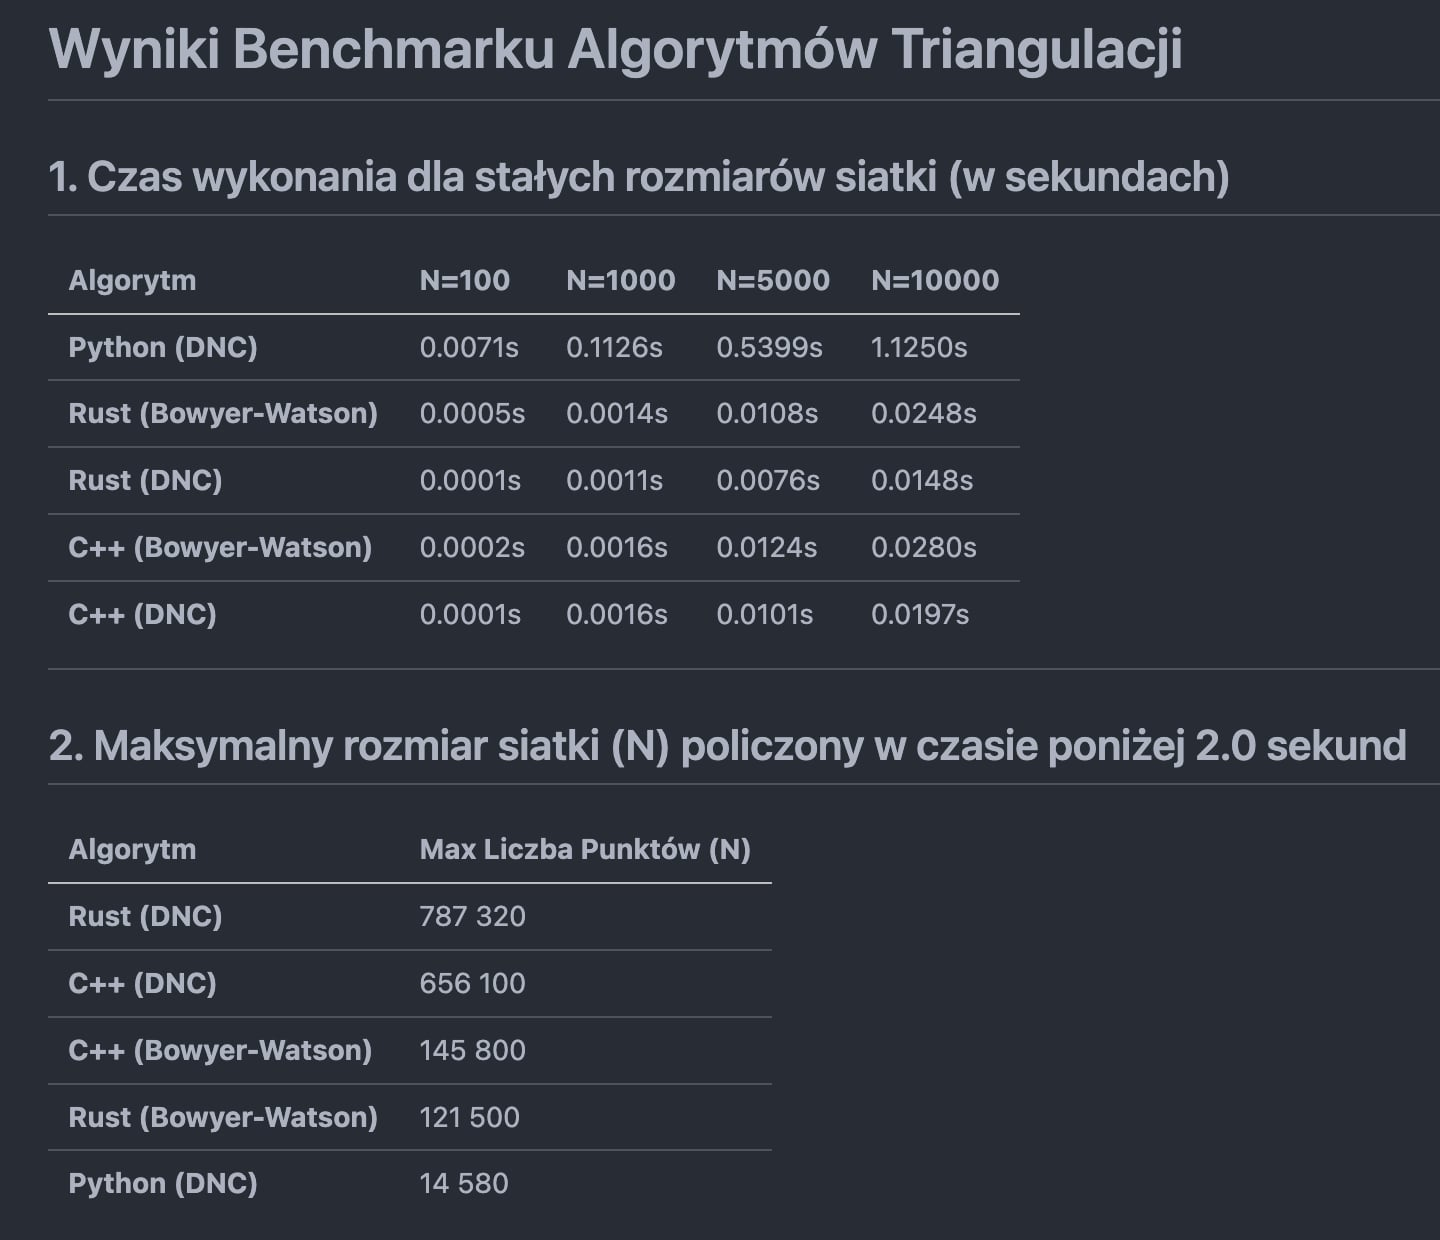

Obie biblioteki posiadają funkcję triangulate_points i triangulate_points_dnc odpowiadające dwóm róznym metodom triangulacji
```python
triangulation = dncpp.triangulate_points(points_to_triangulate)
triangulation = dncpp.triangulate_points_dnc(points_to_triangulate)
triangulation = dnrst.triangulate_points(points_to_triangulate)
triangulation = dnrst.triangulate_points_dnc(points_to_triangulate)
```

Dodatkowo funkcje `triangulate_points` przyjmują argument `use_walk` determinujący sposób wykonania algorytmu

# 4. Wydajność
Przetestowano wydajność funkcji bibliotecznych i porównano z implementacją w pythonie

In [ ]:
from IPython.display import display, Markdown
with open("benchmark_wyniki.md", "r", encoding="utf-8") as f:
    text = f.read()

display(Markdown(text))

Można zaobserwować że dla algorytmów wymagających dużej ilości operacji geometrycznych na krawędziach czysty python nie jest nawet bliski wydajności obu języków.

# Wnioski

Największą przewagą rusta dla osoby uczącej się obydwu języków jest brak 40-letniej wstecznej kompatybilności jak ma to miejsce w c++.
Dodatkowo mimo że rust jest bardziej ograniczający, powiedziałbym że dla nowego programisty zmienia się to w wolnośc. Pisząc w c++ programista musi cały czas trzymać się na baczności i wiedzieć dokładnie jakie dodatkowe problemy może wywołać linijka kodu którą właśnie napisał.